In [1]:
%matplotlib widget

import xbox_proc # Structure, DateRange
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nptdms import TdmsFile
from datetime import datetime

In [2]:
#keys = ["Timestamp", "Line 1 Pressure", "Line 2 Pressure", "DUT 1 Room Temp", "DUT 2 Room Temp", "Pulse Count 2", "Load 2 Pressure", "DUT 2 Pressure", "StructureBSurf_In Temp", "StructureBSurf_Out Temp", "StructureBWater_In Temp", "Load2 Temp", "DUT 2 Flow", "Pulse Count 1", "Load 1 Pressure", "DUT 1 Pressure", "DUT 1 Surf In Temp", "DUT 1 Surf Out Temp", "DUT 1 Water In Temp", "Load 1 RF In Temp", "DUT 1 Flow"]
keys = ["Timestamp", 'Klystron A Pressure', 'Hybrid 1 Pressure', 'Pulse Compressor 1 Pressure', 'Line 1 Pressure', "DUT 1 Pressure",'Load 1 Pressure',
        '1PKIA_ampcursor Blue mean ', '1PKIB_ampcursor Blue mean ', '1PLIA_ampcursor Blue mean ', '1PLIB_ampcursor Blue mean ', '1PSI_ampcursor grey mean ', 
        'Gauge Klystron A Pressure', 'Gauge PC 1 Pressure', 'Gauge Line 1 Pressure',  'Gauge Load 1 Pressure', 'Gauge Klystron B Pressure', 'Gauge DUT 1 Pressure',
        'Repetition rate']

s = xbox_proc.Structure(
    name="Xbox3_TD26CIEMAT_L1",
    data_dir="//cernbox-drive/winspaces/x/xboxes/Xbox3_TD26CIEMAT_L1",
    xbox=3,
    stand=1,
   
    P_ref = 42.3,  # [MW]
    G_ref = 100,  # MV/m
    t_fill=57.25e-9,
    
    BDR_ref=1.7e-6,
    PL_ref=180, # ns

    trend_keys=keys
    )

In [3]:
dr = xbox_proc.DateRange(20260127, 20260128)

In [4]:
event_df = s.extract_events(
    dr,
    out_h5="../data/20260127_event_data.h5",
    key="event_data",
    mode="w"   # overwrite for this test (append 'a' otherwise)
)

event_df.head()

,pulse_count,log_type,timestamp,PKIA_amp_total_power,PKIA_amp_length,PKIA_amp_peak,PKIA_amp_mean,PKIA_amp_start,PKIB_amp_total_power,PKIB_amp_length,...,PEIA_peak_length,PEIA_mean_flat,PEIA_start,PEIA_t,DC_up_total_A,DC_up_peak_A,DC_down_total_A,DC_down_peak_A,BD_struct,BD_loc
0,494425277,3,2026-01-27 15:51:16.574569,0.011472,0.000005,2322.1000,2298.215108,0.000000e+00,0.025420,0.000005,...,4.775000e-07,2.326788e+04,7.500000e-09,0.000000,-0.000316,-52,-0.000271,-42,0,0
1,494425277,0,2026-01-27 15:51:22.964368,0.011550,0.000005,2488.4200,2323.571333,0.000000e+00,0.025252,0.000005,...,2.912500e-07,2.410583e+04,4.375000e-09,0.000000,-0.000316,-52,-0.000280,-45,0,0
2,494425277,2,2026-01-27 15:51:23.007370,0.331094,0.000001,366377.5026,205775.455911,7.131250e-07,0.339441,0.000001,...,1.125000e-08,1.068627e+06,6.631250e-07,0.000002,-0.000317,-53,-0.000276,-45,1,1
3,494428020,0,2026-01-27 15:51:49.144395,0.187718,0.000001,202947.4452,114317.475333,7.175000e-07,0.142502,0.000001,...,7.500000e-09,3.730344e+05,6.568750e-07,0.000000,-0.000319,-54,-0.000282,-43,0,0
4,494428036,2,2026-01-27 15:51:49.188452,0.187576,0.000001,207265.0326,114629.847400,7.131250e-07,0.143048,0.000001,...,1.187500e-08,4.047513e+05,6.568750e-07,0.000002,-0.000316,-52,-0.000274,-43,1,1


In [11]:
# Load the event_data df in s object
s.load(path="../data/20260127_event_data.h5", key="event_data")
s.post_process()

df_event = s.df

In [13]:
print(df_event.keys())

Index(['pulse_count', 'log_type', 'timestamp', 'PKIA_amp_total_power',
       'PKIA_amp_length', 'PKIA_amp_peak', 'PKIA_amp_mean', 'PKIA_amp_start',
       'PKIB_amp_total_power', 'PKIB_amp_length', 'PKIB_amp_peak',
       'PKIB_amp_mean', 'PKIB_amp_start', 'PKRA_total_power', 'PKRA_length',
       'PKRA_peak', 'PKRA_mean', 'PKRA_start', 'PKRB_total_power',
       'PKRB_length', 'PKRB_peak', 'PKRB_mean', 'PKRB_start',
       'PLRA_total_power', 'PLRB_total_power', 'PSIA_total_power', 'PSIA_peak',
       'PSIA_peak_length', 'PSIA_mean_flat', 'PSIA_start', 'PSIA_t',
       'PSRA_total_power', 'PSRA_total_power_including_offset', 'PSRA_t',
       'PEIA_total_power', 'PEIA_peak', 'PEIA_peak_length', 'PEIA_mean_flat',
       'PEIA_start', 'PEIA_t', 'DC_up_total_A', 'DC_up_peak_A',
       'DC_down_total_A', 'DC_down_peak_A', 'BD_struct', 'BD_loc',
       'lost_power_A', 'cum_BD_Load_A', 'cum_BD_DUT_withDC_A',
       'cum_BD_DUT_withoutDC_A', 'cum_BD_HyPC_A', 'BDR_DUT_A', 'BDR_Load_A',
      

In [5]:
trend_df = s.extract_trends(
    dr,
    out_h5="../data/20260127_trend_data.h5",
    key="trend_data",
    mode="w"
)

trend_df.head()

,Timestamp,Klystron A Pressure,Hybrid 1 Pressure,Pulse Compressor 1 Pressure,Line 1 Pressure,Load 1 Pressure,DUT 1 Pressure,1PKIA_ampcursor Blue mean,1PKIB_ampcursor Blue mean,1PLIA_ampcursor Blue mean,1PLIB_ampcursor Blue mean,1PSI_ampcursor grey mean,Repetition rate
0,2026-01-27 15:50:11.769322395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf
1,2026-01-27 15:50:12.738990307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000001
2,2026-01-27 15:50:13.738988876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000001
3,2026-01-27 15:50:14.738986969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000001
4,2026-01-27 15:50:15.738996506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000001


In [6]:
s.load(path="../data/20260127_trend_data.h5", key="trend_data")
df_trend = s.df

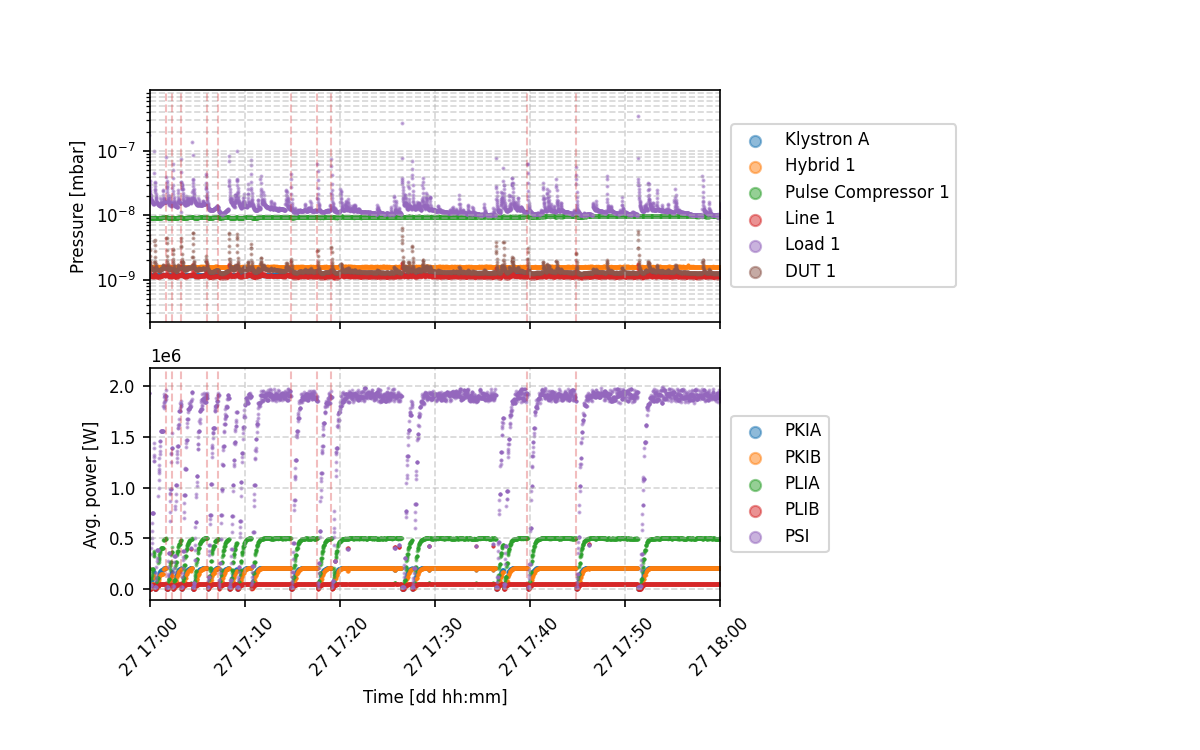

In [37]:
plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 10,
    'legend.fontsize': 8,
    'lines.linewidth': 1})

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True, dpi=150)

plot_keys_trend = ['Klystron A Pressure', 'Hybrid 1 Pressure', 'Pulse Compressor 1 Pressure', 'Line 1 Pressure', 'Load 1 Pressure', 'DUT 1 Pressure']
labels_trend = ['Klystron A', 'Hybrid 1', 'Pulse Compressor 1', 'Line 1', 'Load 1', 'DUT 1']
plot_keys_power = ['1PKIA_ampcursor Blue mean ', '1PKIB_ampcursor Blue mean ', '1PLIA_ampcursor Blue mean ', '1PLIB_ampcursor Blue mean ', '1PSI_ampcursor grey mean ']
labels_power = ['PKIA', 'PKIB', 'PLIA', 'PLIB',  'PSI']

for idx, el in enumerate(plot_keys_trend):
    ax[0].scatter(df_trend['Timestamp'], df_trend[el], label=labels_trend[idx], s=0.8, alpha = 0.5)
ax[0].set_yscale('log')

for idx, el in enumerate(plot_keys_power):
    ax[1].scatter(df_trend['Timestamp'], df_trend[el], label=labels_power[idx], s=0.8, alpha = 0.5)


df_e_f = df_event.query("log_type==2")
df_e_f = df_e_f.query("PKIA_amp_length>10e-9")

for x in df_e_f["timestamp"]:
    ax[0].axvline(x=x, color="tab:red", alpha=0.3, linestyle='--')
    ax[1].axvline(x=x, color="tab:red", alpha=0.3, linestyle='--')

#ax[2].scatter(df_e_f['timestamp'], df_e_f['BD_loc'], s=0.8, alpha = 0.5)

start = pd.Timestamp("2026-01-27 17:00:00")
end   = pd.Timestamp("2026-01-27 18:00:00")

for axs in ax:
    axs.set_xlim(start, end)


for axs in ax:
    axs.grid(True, which='both', linestyle='--', alpha=0.5)
    axs.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        markerscale=6
    )

plt.setp(ax[-1].get_xticklabels(), rotation=45)

#ax[2].plot(df_trend['Timestamp'], df_trend['Repetition rate'])

ax[0].set_ylabel("Pressure [mbar]")
ax[1].set_ylabel("Avg. power [W]")
ax[1].set_xlabel("Time [dd hh:mm]")

# Make room on the right
fig.subplots_adjust(right=0.6, bottom=0.2)

# fig.set_tight_layout
# plt.savefig("../../20261912_1705_RepRate200Hz_Jumping_VacuumActivity.png", bbox_inches='tight', dpi=150)                            